In [2]:
import wfdb
#====================================
# Load ECG record and annotations
#====================================


record = wfdb.rdrecord(r"C:\Users\LapTechnology\PyCharmMiscProject\mit-bih-noise-stress-test-database-1.0.0\\mit-bih-noise-stress-test-database-1.0.0\118e00")
annotation = wfdb.rdann(r"C:\Users\LapTechnology\PyCharmMiscProject\mit-bih-noise-stress-test-database-1.0.0\\mit-bih-noise-stress-test-database-1.0.0\118e00", "atr")


# Print signal shape and first few labels

print(record.p_signal.shape)
print(annotation.symbol[:10])

(650000, 2)
['+', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R']


In [3]:
import numpy as np
import pandas as pd

# Create DataFrame from ECG signal

df = pd.DataFrame(record.p_signal, columns=record.sig_name)

# Initialize empty annotation column

df['annotation'] = np.nan

# Assign annotations to corresponding samples

for i, sample in enumerate(annotation.sample):
    df.loc[sample, 'annotation'] = annotation.symbol[i]

print(df.head())

C:\Users\LapTechnology\AppData\Local\Temp\ipykernel_17904\22602105.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '+' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[sample, 'annotation'] = annotation.symbol[i]


    MLII     V1 annotation
0 -5.955 -5.635        NaN
1 -5.955 -5.635        NaN
2 -5.955 -5.635        NaN
3 -5.955 -5.635        NaN
4 -5.955 -5.635        NaN


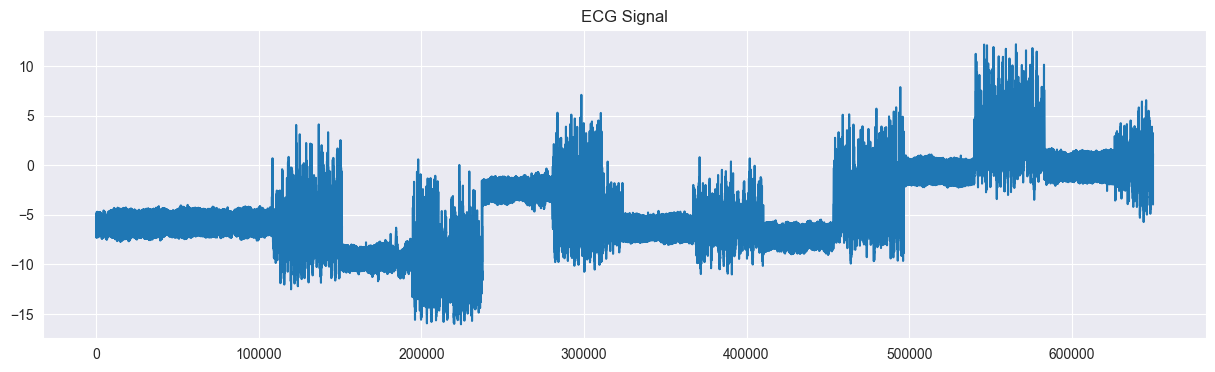

In [4]:
import matplotlib.pyplot as plt

# Plot ECG signal (first channel)

plt.figure(figsize=(15,4))
plt.plot(record.p_signal[:,0])
plt.title("ECG Signal")
plt.show()

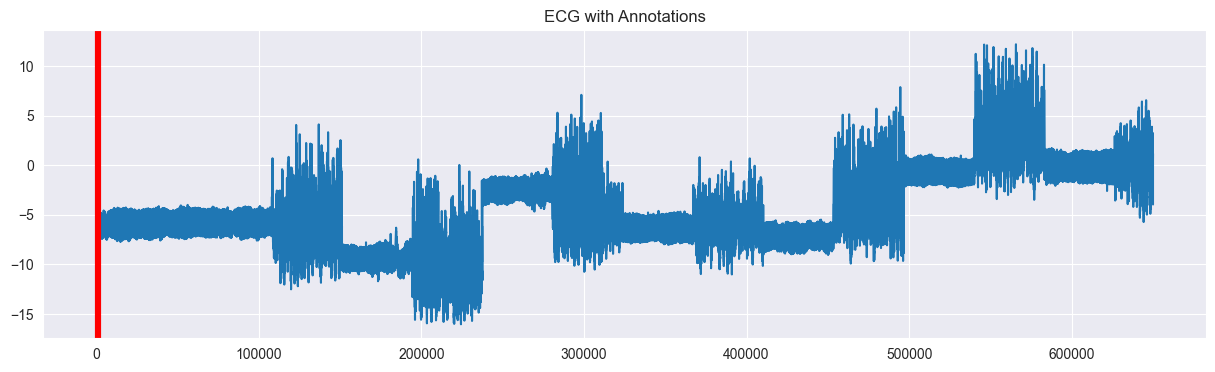

In [5]:
# Plot ECG with annotation markers

plt.figure(figsize=(15,4))
plt.plot(record.p_signal[:,0])

for i in range(10):# first 10 beats only
    plt.axvline(annotation.sample[i], color='r')

plt.title("ECG with Annotations")
plt.show()

In [6]:
import pandas as pd
# Create beats DataFrame

beats = pd.DataFrame({
    "sample": annotation.sample,
    "label": annotation.symbol
})

print(beats.head())

   sample label
0      13     +
1      68     R
2     369     R
3     674     R
4     980     R


In [7]:
# Extract beat segments around each annotation

beats_data = []

window = 100 # number of samples before and after peak

for i, s in enumerate(annotation.sample):
    if s-window > 0 and s+window < len(record.p_signal):
        segment = record.p_signal[s-window:s+window, 0]
        beats_data.append((segment, annotation.symbol[i]))

In [8]:
import numpy as np
# Feature extraction

X = []
y = []

for seg, label in beats_data:
    X.append([
        np.mean(seg),
        np.std(seg),
        np.max(seg),
        np.min(seg)
    ])
    y.append(label)

### Split data and train Random Forest model


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

print(rf_model.score(X_test, y_test))

0.9408695652173913


### Print classification report


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.75      0.10      0.18        29
           R       0.94      1.00      0.97       539
           V       0.00      0.00      0.00         5
           x       0.00      0.00      0.00         1
           ~       0.00      0.00      0.00         1

    accuracy                           0.94       575
   macro avg       0.34      0.22      0.23       575
weighted avg       0.92      0.94      0.92       575



C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

 #### Model performance visualization

Text(0.5, 36.72222222222221, 'Predicted Beat Type')

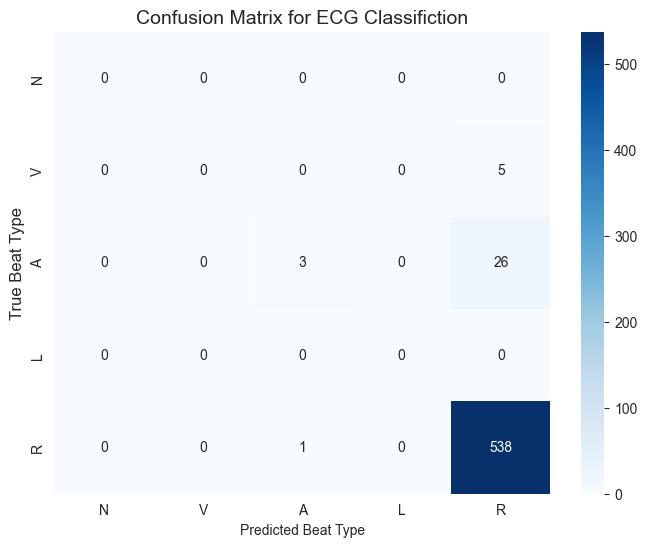

In [11]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['N', 'V', 'A', 'L', 'R'])

plt.figure(figsize=(8, 6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['N', 'V', 'A', 'L', 'R'],
            yticklabels=['N', 'V', 'A', 'L', 'R'])


plt.title('Confusion Matrix for ECG Classifiction', fontsize=14)
plt.ylabel('True Beat Type', fontsize=12)
plt.xlabel('Predicted Beat Type')

In [12]:

import numpy as np
import wfdb
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models


In [13]:
# =========================
#  Load Data
# =========================
path =r"C:\Users\LapTechnology\PyCharmMiscProject\mit-bih-noise-stress-test-database-1.0.0\\mit-bih-noise-stress-test-database-1.0.0\118e00"

record = wfdb.rdrecord(path)
annotation = wfdb.rdann(path, "atr")

In [14]:
# =========================
#  Create Beats Dataset
# =========================
beats_data = []

window = 150

for i, s in enumerate(annotation.sample):

    if s - window > 0 and s + window < len(record.p_signal):

        segment = record.p_signal[s-window:s+window, 0]

        beats_data.append((segment, annotation.symbol[i]))

In [15]:
# =========================
#  Split X, y
# =========================
X = []
y = []

for seg, label in beats_data:
    X.append(seg)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Before reshape:", X.shape)

Before reshape: (2299, 300)


In [16]:

# =========================
#  Encode Labels
# =========================
le = LabelEncoder()
y = le.fit_transform(y)



In [17]:
# =========================
# Reshape for CNN
# =========================
X = X.reshape(X.shape[0], X.shape[1], 1)

print("After reshape:", X.shape)



After reshape: (2299, 300, 1)


In [18]:
# =========================
# Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
# =========================
#  Build CNN Model
# =========================
model = models.Sequential()

model.add(layers.Conv1D(32, kernel_size=5, activation='relu',
                        input_shape=(X.shape[1], 1)))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Conv1D(64, kernel_size=5, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Conv1D(128, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(len(np.unique(y)), activation='softmax'))


C:\Users\LapTechnology\PyCharmMiscProject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# =========================
# Compile Model
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 296, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 148, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 144, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 70, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       286,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,309 (1.23 MB)

 Trainable params: 322,309 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# =========================
#  Train Model
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9250 - loss: 0.4529 - val_accuracy: 0.9413 - val_loss: 0.2956
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9418 - loss: 0.3087 - val_accuracy: 0.9413 - val_loss: 0.2866
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9418 - loss: 0.2976 - val_accuracy: 0.9413 - val_loss: 0.2669
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9418 - loss: 0.2602 - val_accuracy: 0.9413 - val_loss: 0.2675
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9429 - loss: 0.2462 - val_accuracy: 0.9413 - val_loss: 0.2501
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9429 - loss: 0.2326 - val_accuracy: 0.9435 - val_loss: 0.2466
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9440 - loss: 0.2308 - val_accuracy: 0.9435 - val_loss: 0.2328
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9429 - loss: 0.2111 - val_accuracy: 0.9435 - val_los

In [22]:
# =========================
#  Evaluate Model
# =========================
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9435 - loss: 0.2075 
Test Accuracy: 0.9434782862663269


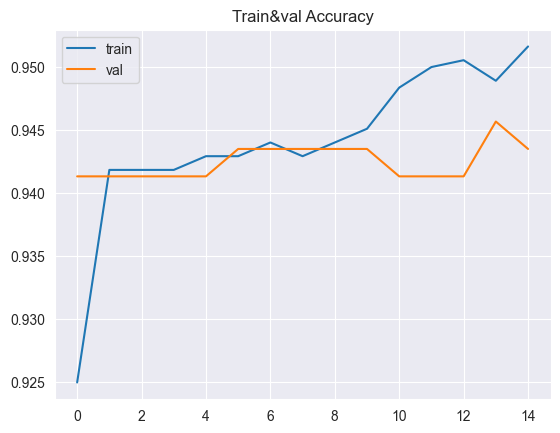

In [23]:
# =========================
#  Plot Training
# =========================
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Train&val Accuracy")
plt.legend()
plt.show()